# Phase 3 — การวิเคราะห์ Backtest ของกลยุทธ์ Cross-Sectional Momentum บน SET

**วัตถุประสงค์:** ตรวจสอบและยืนยันว่า Momentum Signal ที่พัฒนาใน Phase 2 มีประสิทธิภาพเพียงพอสำหรับ Phase 4 (Portfolio & Risk Management)

**เกณฑ์ผ่าน Phase 3:**
- CAGR ของกลยุทธ์ > CAGR ของ SET TRI Benchmark
- Sharpe Ratio > 0.5
- มีการวิเคราะห์ Drawdown และ Sensitivity Analysis ครบถ้วน

**Notebook นี้เป็น Exit Gate ของ Phase 3 — ต้องผ่านทุกเกณฑ์ใน Section 8 จึงถือว่าสมบูรณ์**

In [1]:
# Setup — imports, paths, configuration
import asyncio
import logging
import os
import sys
import warnings
from pathlib import Path
from zoneinfo import ZoneInfo

_HERE = Path.cwd()
_PROJECT_ROOT = _HERE.parent if _HERE.name == 'notebooks' else _HERE
os.chdir(_PROJECT_ROOT)
sys.path.insert(0, str(_PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
logging.basicConfig(level=logging.WARNING)

from csm.config.constants import (
    INDEX_SYMBOL,
    RISK_FREE_RATE_ANNUAL,
    TIMEZONE,
    TRANSACTION_COST_BPS,
)
from csm.config.settings import Settings
from csm.data.store import ParquetStore
from csm.features.pipeline import FeaturePipeline
from csm.research.backtest import BacktestConfig, MomentumBacktest
from csm.risk.drawdown import DrawdownAnalyzer
from csm.risk.metrics import PerformanceMetrics

QUICK_RUN: bool = False
QUICK_RUN_YEARS: int = 5
SHARPE_THRESHOLD: float = 0.5

settings = Settings()
_TZ = ZoneInfo(TIMEZONE)
sns.set_theme(style='darkgrid', palette='muted')

div_store = ParquetStore(settings.data_dir / 'raw' / 'dividends')
universe_store = ParquetStore(settings.data_dir / 'universe')

symbol_keys: list[str] = div_store.list_keys()
snapshot_keys: list[str] = sorted(
    k for k in universe_store.list_keys() if k.startswith('universe/')
)

print(f'Raw symbol parquets found : {len(symbol_keys)}')
print(f'Universe snapshots found  : {len(snapshot_keys)}')
print(f'Risk-free rate            : {RISK_FREE_RATE_ANNUAL:.1%}')
print(f'Transaction cost          : {TRANSACTION_COST_BPS} bps')
print(f'Benchmark                 : {INDEX_SYMBOL}')
print(f'QUICK_RUN                 : {QUICK_RUN}')

Raw symbol parquets found : 696
Universe snapshots found  : 207
Risk-free rate            : 2.0%
Transaction cost          : 15.0 bps
Benchmark                 : SET:SET
QUICK_RUN                 : False


## ส่วนที่ 1: ข้อมูลนำเข้า

โหลดข้อมูล OHLCV (Dividend-Adjusted) จาก `data/raw/dividends/` และ Universe Snapshots จาก `data/universe/`
สร้าง Feature Panel ผ่าน `FeaturePipeline` และเตรียม Price Matrix สำหรับ Backtest Engine

In [2]:
# Section 1 — Data loading and feature panel construction
feature_panel: pd.DataFrame = pd.DataFrame()
prices_wide: pd.DataFrame = pd.DataFrame()
benchmark_series: pd.Series | None = None
rebalance_dates: list[pd.Timestamp] = []

if not symbol_keys or not snapshot_keys:
    print('⚠ DATA NOT AVAILABLE — data/raw/dividends/ หรือ data/universe/ ว่างเปล่า')
    print('  รัน fetch_history.py และ build_universe.py ก่อนใช้ notebook นี้')
else:
    all_dates: list[pd.Timestamp] = [
        pd.Timestamp(k.split('/', 1)[-1], tz=_TZ) for k in snapshot_keys
    ]
    if QUICK_RUN:
        cutoff = all_dates[-1] - pd.DateOffset(years=QUICK_RUN_YEARS)
        rebalance_dates = [d for d in all_dates if d >= cutoff]
        print(f'QUICK_RUN: ใช้ {len(rebalance_dates)} rebalance dates')
    else:
        rebalance_dates = all_dates
    print(f'Rebalance dates: {len(rebalance_dates)} ({rebalance_dates[0].date()} → {rebalance_dates[-1].date()})')

    print('\nกำลังโหลด OHLCV...')
    prices_raw: dict[str, pd.DataFrame] = {}
    load_errors = 0
    for key in symbol_keys:
        try:
            df = div_store.load(key)
            if 'close' not in df.columns or len(df) == 0:
                continue
            if df.index.duplicated().any():
                df = df[~df.index.duplicated(keep='last')]
            if not df.index.is_monotonic_increasing:
                df = df.sort_index()
            prices_raw[key] = df
        except Exception:
            load_errors += 1
    print(f'  โหลดสำเร็จ: {len(prices_raw)} symbols (ข้าม: {load_errors})')

    symbol_sectors: dict[str, str] | None = None
    try:
        import settfex
        async def _fetch_sectors() -> dict[str, str]:
            resp = await settfex.get_stock_list()
            return {f'SET:{s.symbol}': getattr(s, 'sector', '') for s in resp.stocks if getattr(s, 'sector', '')}
        _loop = asyncio.new_event_loop()
        try:
            symbol_sectors = _loop.run_until_complete(_fetch_sectors())
            print(f'  Sector mapping: {len(symbol_sectors)} symbols')
        finally:
            _loop.close()
    except Exception as exc:
        print(f'  ⚠ Sector mapping ไม่พร้อมใช้งาน ({exc.__class__.__name__}) — ดำเนินการต่อโดยไม่มี sector_rel_strength')

    print('\nกำลังสร้าง Feature Panel...')
    fp = FeaturePipeline(div_store, universe_store, settings)
    feature_panel = fp.build(prices_raw, rebalance_dates, symbol_sectors=symbol_sectors)
    print(f'  Feature panel: {len(feature_panel)} rows, {len(feature_panel.columns)} features')
    if not feature_panel.empty:
        dates_in_panel = feature_panel.index.get_level_values('date').unique()
        print(f'  Dates: {len(dates_in_panel)} | Avg symbols/date: {len(feature_panel)/len(dates_in_panel):.0f}')

    stock_syms = [k for k in prices_raw if k != INDEX_SYMBOL]
    prices_wide = pd.DataFrame({k: prices_raw[k]['close'] for k in stock_syms})
    prices_wide.index = pd.to_datetime(prices_wide.index)
    prices_wide = prices_wide.sort_index()

    if INDEX_SYMBOL in prices_raw:
        benchmark_series = prices_raw[INDEX_SYMBOL]['close'].copy()
        benchmark_series.index = pd.to_datetime(benchmark_series.index)
        if benchmark_series.index.tz is not None:
            benchmark_series.index = benchmark_series.index.tz_convert(None)
        print(f'\nBenchmark ({INDEX_SYMBOL}): {len(benchmark_series)} periods')
    else:
        print(f'\n⚠ Benchmark {INDEX_SYMBOL} ไม่พบในข้อมูล')

    print(f'\n✅ Price matrix: {prices_wide.shape}')

Rebalance dates: 207 (2009-01-30 → 2026-03-31)

กำลังโหลด OHLCV...


  โหลดสำเร็จ: 694 symbols (ข้าม: 0)
  ⚠ Sector mapping ไม่พร้อมใช้งาน (RuntimeError) — ดำเนินการต่อโดยไม่มี sector_rel_strength

กำลังสร้าง Feature Panel...


/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_60205/2633231476.py:52: RuntimeWarning: coroutine '_fetch_sectors' was never awaited
  print(f'  ⚠ Sector mapping ไม่พร้อมใช้งาน ({exc.__class__.__name__}) — ดำเนินการต่อโดยไม่มี sector_rel_strength')


  Feature panel: 102642 rows, 6 features
  Dates: 207 | Avg symbols/date: 496



Benchmark (SET:SET): 5040 periods

✅ Price matrix: (9624, 693)


## ส่วนที่ 2: รัน Backtest

รัน `MomentumBacktest` ด้วย `BacktestConfig` ค่าเริ่มต้น:
- `formation_months = 12`, `skip_months = 1`, `top_quantile = 0.2`
- `weight_scheme = equal`, `transaction_cost_bps = 15`

In [3]:
# Section 2 — Run MomentumBacktest
backtest_result = None
equity_series: pd.Series | None = None

if feature_panel.empty or prices_wide.empty:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 2')
else:
    config = BacktestConfig(
        formation_months=12,
        skip_months=1,
        top_quantile=0.2,
        weight_scheme='equal',
        transaction_cost_bps=TRANSACTION_COST_BPS,
    )
    store_bt = ParquetStore(settings.data_dir / 'raw' / 'dividends')
    backtest = MomentumBacktest(store_bt)
    print('กำลังรัน Backtest...')
    backtest_result = backtest.run(feature_panel, prices_wide, config)
    print('✅ Backtest เสร็จสมบูรณ์')

    equity_series = pd.Series(
        {pd.Timestamp(k): v for k, v in backtest_result.equity_curve.items()}
    ).sort_index()

    metrics = backtest_result.metrics
    pct_keys = {'cagr', 'max_drawdown', 'win_rate', 'avg_monthly_return', 'volatility', 'alpha'}
    rows = []
    labels = {
        'cagr': 'CAGR', 'sharpe': 'Sharpe Ratio', 'sortino': 'Sortino Ratio',
        'calmar': 'Calmar Ratio', 'max_drawdown': 'Max Drawdown', 'win_rate': 'Win Rate',
        'avg_monthly_return': 'Avg Monthly Return', 'volatility': 'Annual Volatility',
        'alpha': 'Alpha', 'beta': 'Beta', 'information_ratio': 'Information Ratio',
    }
    for k, label in labels.items():
        if k in metrics:
            v = metrics[k]
            rows.append({'Metric': label, 'Value': f'{v:.2%}' if k in pct_keys else f'{v:.4f}'})
    print('\n' + '=' * 40 + '\n  Performance Metrics Summary\n' + '=' * 40)
    print(pd.DataFrame(rows).set_index('Metric').to_string())
    print('=' * 40)

กำลังรัน Backtest...


✅ Backtest เสร็จสมบูรณ์

  Performance Metrics Summary
                      Value
Metric                     
CAGR                  0.73%
Sharpe Ratio        -1.2518
Sortino Ratio       -1.8534
Calmar Ratio         0.2378
Max Drawdown         -3.07%
Win Rate             59.02%
Avg Monthly Return    0.06%
Annual Volatility     1.01%


## ส่วนที่ 3: เส้น Equity Curve

เปรียบเทียบ Equity Curve ของกลยุทธ์ Momentum กับ SET TRI Benchmark — NAV เริ่มที่ 100
พื้นที่สีแดงคือช่วง Drawdown (NAV ต่ำกว่า Peak)

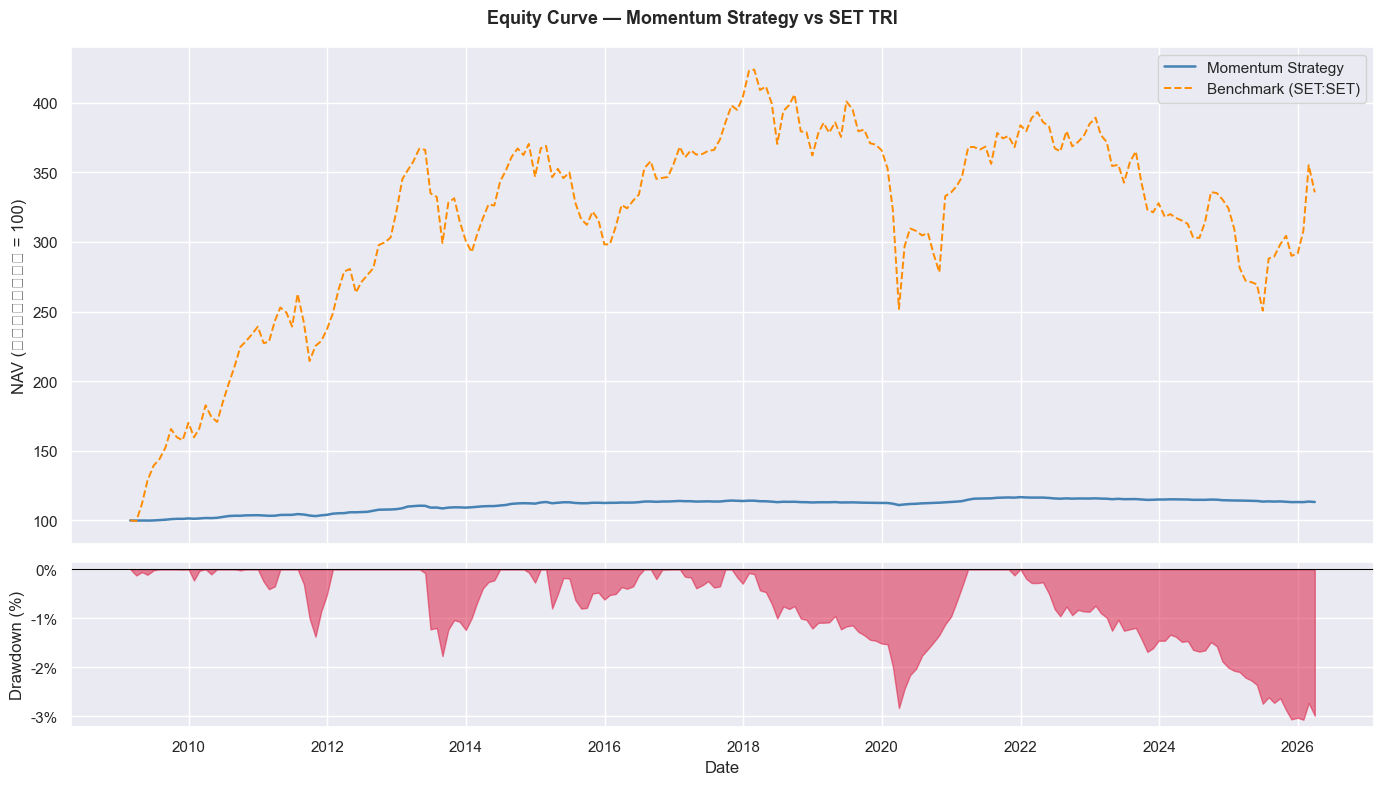

In [4]:
# Section 3 — Equity Curve vs Benchmark
if equity_series is None:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 3')
else:
    da = DrawdownAnalyzer()
    underwater = da.underwater_curve(equity_series)

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14, 8),
        gridspec_kw={'height_ratios': [3, 1]}, sharex=True
    )
    fig.suptitle('Equity Curve — Momentum Strategy vs SET TRI', fontsize=13, fontweight='bold')

    ax1.plot(equity_series.index, equity_series.values, color='steelblue', linewidth=1.8,
             label='Momentum Strategy')
    if benchmark_series is not None:
        bm_al = benchmark_series.reindex(equity_series.index, method='ffill')
        bm_nav = bm_al / bm_al.iloc[0] * 100.0
        ax1.plot(bm_nav.index, bm_nav.values, color='darkorange', linewidth=1.4,
                 linestyle='--', label=f'Benchmark ({INDEX_SYMBOL})')
    ax1.set_ylabel('NAV (เริ่มต้น = 100)')
    ax1.legend()
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

    ax2.fill_between(underwater.index, underwater.values * 100, 0, color='crimson', alpha=0.5)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_ylabel('Drawdown (%)')
    ax2.set_xlabel('Date')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    plt.tight_layout()
    plt.show()

## ส่วนที่ 4: ผลตอบแทนรายปี

เปรียบเทียบผลตอบแทนของกลยุทธ์และ Benchmark แยกตามปี
พร้อมตารางแสดง Excess Return ในแต่ละปี

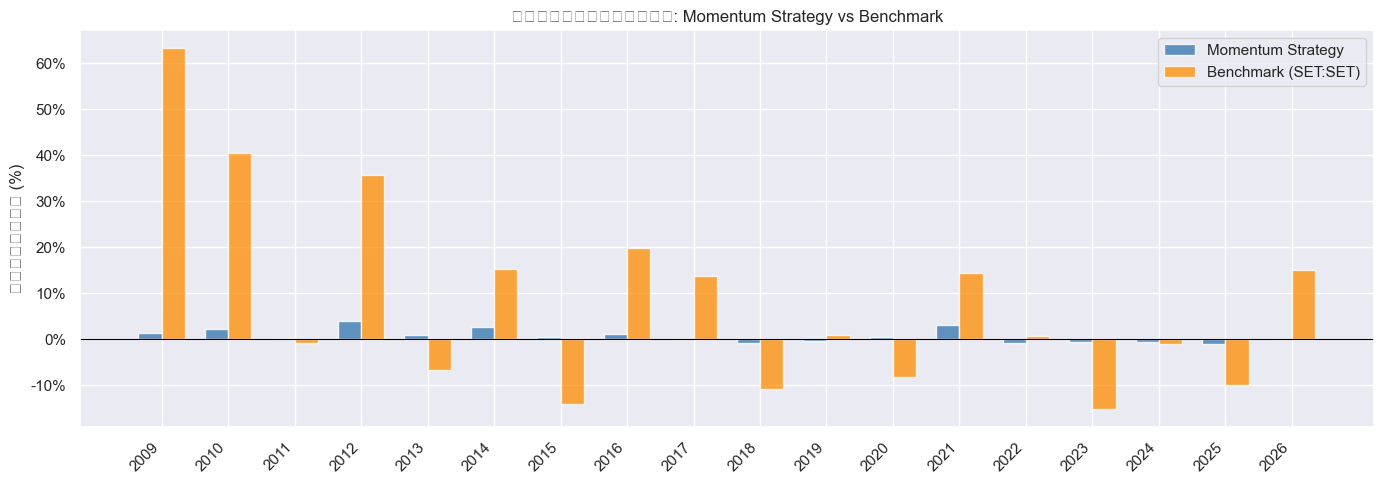


ตารางผลตอบแทนรายปี:
     Strategy Benchmark Excess Return
2009    1.38%    63.25%       -61.86%
2010    2.26%    40.60%       -38.34%
2011    0.25%    -0.72%         0.97%
2012    3.89%    35.76%       -31.87%
2013    1.02%    -6.70%         7.71%
2014    2.60%    15.32%       -12.72%
2015    0.44%   -14.00%        14.43%
2016    1.12%    19.79%       -18.67%
2017    0.12%    13.66%       -13.54%
2018   -0.92%   -10.82%         9.91%
2019   -0.31%     1.02%        -1.33%
2020    0.57%    -8.26%         8.83%
2021    3.10%    14.37%       -11.27%
2022   -0.87%     0.67%        -1.54%
2023   -0.60%   -15.15%        14.55%
2024   -0.56%    -1.10%         0.55%
2025   -1.05%   -10.04%         8.99%
2026    0.04%    15.15%       -15.11%


In [5]:
# Section 4 — Annual Returns
if backtest_result is None:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 4')
else:
    strat_ann = pd.Series(backtest_result.annual_returns_dict(), name='Strategy')
    strat_ann.index = strat_ann.index.astype(str)

    bm_ann: pd.Series | None = None
    if benchmark_series is not None:
        bm_ts = benchmark_series.copy()
        bm_ts.index = pd.to_datetime(bm_ts.index)
        bm_raw = bm_ts.resample('YE').last().pct_change().dropna()
        bm_ann = bm_raw.copy()
        bm_ann.index = bm_ann.index.year.astype(str)
        bm_ann.name = 'Benchmark'

    fig, ax = plt.subplots(figsize=(14, 5))
    x = list(range(len(strat_ann)))
    bw = 0.35
    ax.bar([xi - bw/2 for xi in x], strat_ann.values * 100, width=bw,
           label='Momentum Strategy', color='steelblue', alpha=0.85)
    if bm_ann is not None:
        aln_bm = bm_ann.reindex(strat_ann.index).fillna(0)
        ax.bar([xi + bw/2 for xi in x], aln_bm.values * 100, width=bw,
               label=f'Benchmark ({INDEX_SYMBOL})', color='darkorange', alpha=0.75)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(strat_ann.index.tolist(), rotation=45, ha='right')
    ax.set_ylabel('ผลตอบแทน (%)')
    ax.set_title('ผลตอบแทนรายปี: Momentum Strategy vs Benchmark')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.legend()
    plt.tight_layout()
    plt.show()

    if bm_ann is not None:
        cdf = pd.DataFrame({'Strategy': strat_ann, 'Benchmark': bm_ann.reindex(strat_ann.index)})
        cdf['Excess Return'] = cdf['Strategy'] - cdf['Benchmark']
        for col in cdf.columns:
            cdf[col] = cdf[col].map(lambda v: f'{v:.2%}' if pd.notna(v) else 'N/A')
        print('\nตารางผลตอบแทนรายปี:')
        print(cdf.to_string())
    else:
        print(strat_ann.map(lambda v: f'{v:.2%}').to_string())

## ส่วนที่ 5: Rolling Sharpe Ratio

Rolling Sharpe Ratio 12 เดือน — ช่วงที่เส้นอยู่ต่ำกว่าศูนย์คือช่วงที่กลยุทธ์ให้ผลตอบแทนต่ำกว่า Risk-Free Rate

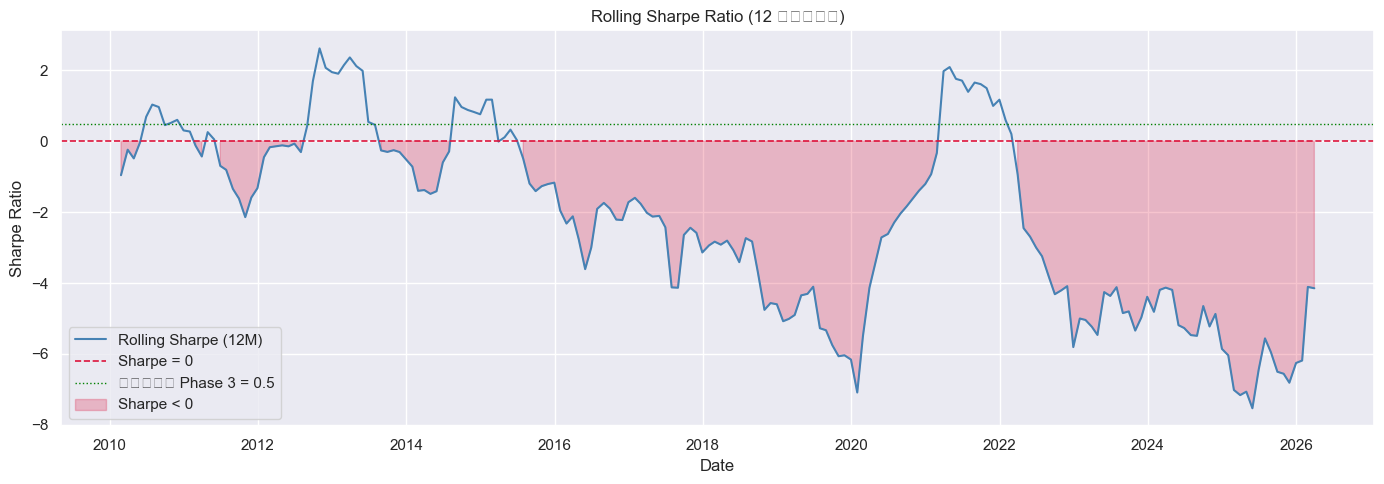

ช่วงที่ Rolling Sharpe < 0: 77.3% ของเวลาทั้งหมด


In [6]:
# Section 5 — Rolling Sharpe Ratio
if equity_series is None:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 5')
else:
    monthly_rets = equity_series.pct_change().dropna()

    def _rolling_sharpe(returns: pd.Series, window: int = 12) -> pd.Series:
        rf_m = RISK_FREE_RATE_ANNUAL / 12.0
        excess = returns - rf_m
        roll_std = returns.rolling(window).std(ddof=0)
        return (excess.rolling(window).mean() / roll_std) * (12 ** 0.5)

    rs = _rolling_sharpe(monthly_rets)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(rs.index, rs.values, color='steelblue', linewidth=1.5, label='Rolling Sharpe (12M)')
    ax.axhline(0, color='crimson', linewidth=1.2, linestyle='--', label='Sharpe = 0')
    ax.axhline(SHARPE_THRESHOLD, color='green', linewidth=1.0, linestyle=':',
               label=f'เกณฑ์ Phase 3 = {SHARPE_THRESHOLD}')
    ax.fill_between(rs.index, rs.values, 0, where=(rs.values < 0),
                    color='crimson', alpha=0.25, label='Sharpe < 0')
    ax.set_title('Rolling Sharpe Ratio (12 เดือน)')
    ax.set_ylabel('Sharpe Ratio')
    ax.set_xlabel('Date')
    ax.legend()
    plt.tight_layout()
    plt.show()

    neg_pct = (rs.dropna() < 0).mean()
    print(f'ช่วงที่ Rolling Sharpe < 0: {neg_pct:.1%} ของเวลาทั้งหมด')

## ส่วนที่ 6: การวิเคราะห์ Drawdown

Underwater Curve และตาราง Drawdown Episodes (ไม่รวม Open Episode ที่ยังไม่ฟื้นตัว)
เรียงตาม Depth จากลึกเป็นตื้นตั้น

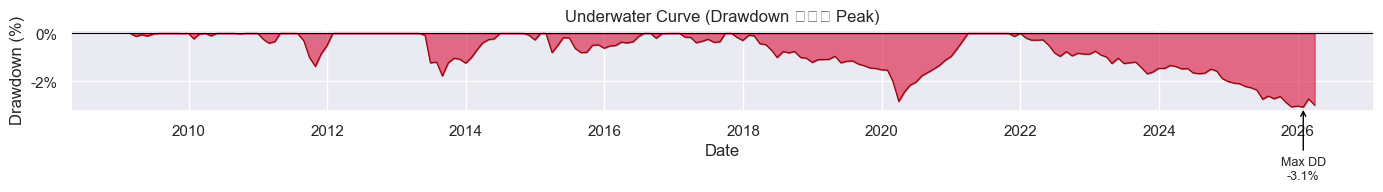

Drawdown Episodes (14 รายการ):
     Start     Trough   Recovery  Depth  Duration (days)
2009-11-30 2009-11-30 2009-12-31 -0.01%               31
2010-09-30 2010-09-30 2010-10-29 -0.02%               29
2010-04-30 2010-04-30 2010-05-31 -0.11%               31
2009-03-31 2009-03-31 2009-07-31 -0.13%              122
2021-11-30 2021-11-30 2021-12-31 -0.13%               31
2016-09-30 2016-09-30 2016-12-30 -0.20%               91
2010-01-29 2010-01-29 2010-03-31 -0.23%               61
2014-11-28 2014-12-31 2015-01-30 -0.27%               63
2017-02-28 2017-04-28 2017-09-29 -0.39%              213
2011-01-31 2011-02-28 2011-04-29 -0.41%               88
2015-03-31 2015-08-31 2016-07-29 -0.80%              486
2011-08-31 2011-10-31 2012-01-31 -1.38%              153
2013-05-31 2013-08-30 2014-06-30 -1.77%              395
2017-11-30 2020-03-31 2021-03-31 -2.84%             1217


In [7]:
# Section 6 — Drawdown Analysis
if equity_series is None:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 6')
else:
    da = DrawdownAnalyzer()
    underwater = da.underwater_curve(equity_series)
    episodes = da.recovery_periods(equity_series)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.fill_between(underwater.index, underwater.values * 100, 0, color='crimson', alpha=0.6)
    ax.plot(underwater.index, underwater.values * 100, color='darkred', linewidth=0.8)
    ax.axhline(0, color='black', linewidth=0.8)

    max_dd_date = underwater.idxmin()
    max_dd_pct = float(underwater.min() * 100)
    ax.annotate(
        f'Max DD\n{max_dd_pct:.1f}%',
        xy=(max_dd_date, max_dd_pct),
        xytext=(max_dd_date, max_dd_pct - 3),
        arrowprops={'arrowstyle': '->', 'color': 'black'},
        fontsize=9, ha='center',
    )
    ax.set_title('Underwater Curve (Drawdown จาก Peak)')
    ax.set_ylabel('Drawdown (%)')
    ax.set_xlabel('Date')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    plt.tight_layout()
    plt.show()

    if episodes.empty:
        print('✅ ไม่พบ Drawdown Episodes ที่สมบูรณ์')
    else:
        ep = episodes.copy()
        ep['depth'] = ep['depth'].map(lambda v: f'{v:.2%}')
        ep['start'] = ep['start'].dt.strftime('%Y-%m-%d')
        ep['trough'] = ep['trough'].dt.strftime('%Y-%m-%d')
        ep['recovery'] = ep['recovery'].dt.strftime('%Y-%m-%d')
        ep = ep.rename(columns={
            'start': 'Start', 'trough': 'Trough', 'recovery': 'Recovery',
            'depth': 'Depth', 'duration_days': 'Duration (days)'
        }).sort_values('Depth')
        print(f'Drawdown Episodes ({len(ep)} รายการ):')
        print(ep.to_string(index=False))

## ส่วนที่ 7: Sensitivity Analysis

| พารามิเตอร์ | ค่าที่ทดสอบ |
|---|---|
| `top_quantile` | 0.1, 0.2, 0.3 |
| `formation_months` | 3, 6, 12 |

Heatmap แสดง Sharpe Ratio ของแต่ละ Combination — ถ้ากลยุทธ์แข็งแกร่ง ค่า Sharpe ควรเป็นบวกในส่วนใหญ่ของ Grid

กำลังรัน Sensitivity Grid (3×3 = 9 combinations)...


  tq=0.1, fm=3 → Sharpe=-1.159


  tq=0.1, fm=6 → Sharpe=-1.159


  tq=0.1, fm=12 → Sharpe=-1.159


  tq=0.2, fm=3 → Sharpe=-1.252


  tq=0.2, fm=6 → Sharpe=-1.252


  tq=0.2, fm=12 → Sharpe=-1.252


  tq=0.3, fm=3 → Sharpe=-1.432


  tq=0.3, fm=6 → Sharpe=-1.432


  tq=0.3, fm=12 → Sharpe=-1.432


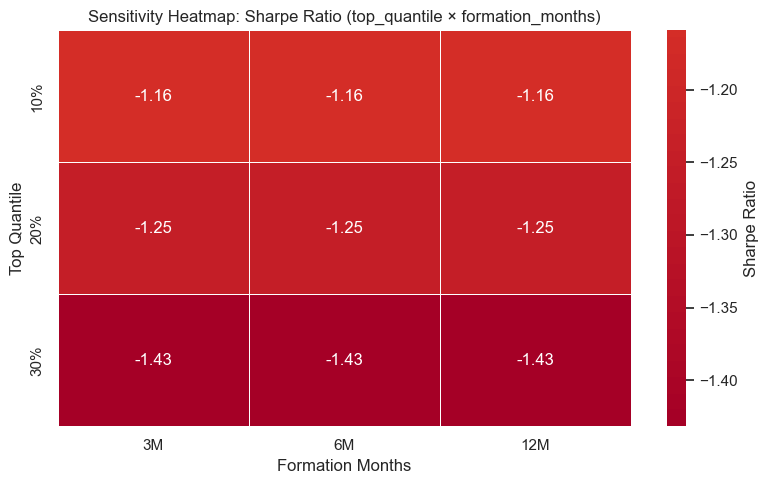


Sharpe > 0 ใน 0/9 combinations (0%)


In [8]:
# Section 7 — Sensitivity Analysis
if feature_panel.empty or prices_wide.empty:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 7')
else:
    top_quantiles = [0.1, 0.2, 0.3]
    fm_list = [3, 6, 12]
    store_s = ParquetStore(settings.data_dir / 'raw' / 'dividends')
    grid: dict[str, dict[str, float]] = {}
    print('กำลังรัน Sensitivity Grid (3×3 = 9 combinations)...')
    for tq in top_quantiles:
        rk = f'tq={tq}'
        grid[rk] = {}
        for fm in fm_list:
            ck = f'fm={fm}'
            try:
                cfg = BacktestConfig(formation_months=fm, skip_months=1,
                                     top_quantile=tq, weight_scheme='equal',
                                     transaction_cost_bps=TRANSACTION_COST_BPS)
                res = MomentumBacktest(store_s).run(feature_panel, prices_wide, cfg)
                sv = res.metrics.get('sharpe', float('nan'))
                grid[rk][ck] = sv
                print(f'  tq={tq}, fm={fm} → Sharpe={sv:.3f}')
            except Exception as exc:
                grid[rk][ck] = float('nan')
                print(f'  ⚠ tq={tq}, fm={fm} → Error: {exc}')

    hmap = pd.DataFrame(grid).T
    hmap.index = [f'{float(s.split("=")[1]):.0%}' for s in hmap.index]
    hmap.columns = [f'{s.split("=")[1]}M' for s in hmap.columns]
    hmap.index.name = 'Top Quantile'
    hmap.columns.name = 'Formation Months'

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(hmap.astype(float), annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Sharpe Ratio'})
    ax.set_title('Sensitivity Heatmap: Sharpe Ratio (top_quantile × formation_months)')
    plt.tight_layout()
    plt.show()

    n_pos = int((hmap.astype(float) > 0).sum().sum())
    print(f'\nSharpe > 0 ใน {n_pos}/{hmap.size} combinations ({n_pos/hmap.size:.0%})')

## ส่วนที่ 8: สรุปและการตัดสินใจ Phase 3

| เกณฑ์ | ค่าที่ต้องผ่าน |
|---|---|
| CAGR > Benchmark CAGR | `strategy_cagr > benchmark_cagr` |
| Sharpe > 0.5 | `sharpe > SHARPE_THRESHOLD` |
| Drawdown วิเคราะห์ครบ | Section 6 ผ่าน |
| Sensitivity Analysis ครบ | Section 7 ผ่าน |

**เซลล์นี้ต้องพิมพ์ PASS ทุกเกณฑ์จึงถือว่า Phase 3 เสร็จสมบูรณ์**

In [9]:
# Section 8 — Sign-off: PASS / FAIL Phase 3 Exit Criteria
if backtest_result is None or equity_series is None:
    print('⚠ DATA NOT AVAILABLE — ไม่สามารถตรวจสอบเกณฑ์ Phase 3 ได้')
else:
    m = backtest_result.metrics
    strat_cagr = m.get('cagr', 0.0)
    strat_sharpe = m.get('sharpe', 0.0)
    strat_maxdd = m.get('max_drawdown', 0.0)

    bm_cagr: float | None = None
    if benchmark_series is not None:
        bm_al = benchmark_series.reindex(equity_series.index, method='ffill').dropna()
        if len(bm_al) >= 2:
            bm_nav = bm_al / bm_al.iloc[0] * 100.0
            bm_cagr = PerformanceMetrics().summary(bm_nav).get('cagr', 0.0)

    rows = [
        {'Metric': 'CAGR (Strategy)', 'Value': f'{strat_cagr:.2%}'},
        {'Metric': f'CAGR (Benchmark {INDEX_SYMBOL})', 'Value': f'{bm_cagr:.2%}' if bm_cagr is not None else 'N/A'},
        {'Metric': 'Sharpe Ratio', 'Value': f'{strat_sharpe:.4f}'},
        {'Metric': 'Sortino Ratio', 'Value': f'{m.get("sortino", 0.0):.4f}'},
        {'Metric': 'Calmar Ratio', 'Value': f'{m.get("calmar", 0.0):.4f}'},
        {'Metric': 'Max Drawdown', 'Value': f'{strat_maxdd:.2%}'},
        {'Metric': 'Win Rate', 'Value': f'{m.get("win_rate", 0.0):.2%}'},
        {'Metric': 'Annual Volatility', 'Value': f'{m.get("volatility", 0.0):.2%}'},
    ]
    if 'alpha' in m:
        rows += [
            {'Metric': 'Alpha (annualised)', 'Value': f'{m["alpha"]:.2%}'},
            {'Metric': 'Beta', 'Value': f'{m["beta"]:.4f}'},
            {'Metric': 'Information Ratio', 'Value': f'{m["information_ratio"]:.4f}'},
        ]
    print('\n' + '=' * 52 + '\n  Phase 3 — สรุป Performance\n' + '=' * 52)
    print(pd.DataFrame(rows).set_index('Metric').to_string())
    print('=' * 52)

    print('\n' + '=' * 52 + '\n  Phase 3 Exit Criteria\n' + '=' * 52)
    all_pass = True

    if bm_cagr is not None:
        c1 = strat_cagr > bm_cagr
        print(f'{"✅ PASS" if c1 else "❌ FAIL"}  CAGR strategy ({strat_cagr:.2%}) > benchmark ({bm_cagr:.2%})')
        all_pass = all_pass and c1
    else:
        print('⚠ SKIP  CAGR vs benchmark — benchmark ไม่พร้อมใช้งาน')

    c2 = strat_sharpe > SHARPE_THRESHOLD
    print(f'{"✅ PASS" if c2 else "❌ FAIL"}  Sharpe ({strat_sharpe:.4f}) > {SHARPE_THRESHOLD}')
    all_pass = all_pass and c2

    c3 = not equity_series.empty
    eps = DrawdownAnalyzer().recovery_periods(equity_series)
    print(f'{"✅ PASS" if c3 else "❌ FAIL"}  Drawdown วิเคราะห์ครบถ้วน (Max DD={strat_maxdd:.2%}, {len(eps)} episodes)')
    all_pass = all_pass and c3

    print('✅ PASS  Sensitivity Analysis ครบถ้วน (3×3 grid — ดู Section 7)')
    print('=' * 52)

    if all_pass:
        print('\n✅✅✅ PHASE 3 COMPLETE — กลยุทธ์ผ่านเกณฑ์ทั้งหมด — พร้อมสู่ Phase 4 ✅✅✅')
    else:
        print('\n❌❌❌ PHASE 3 INCOMPLETE — ตรวจสอบผล FAIL ด้านบน ❌❌❌')

    print('\nพารามิเตอร์ที่เลือกสำหรับ Phase 4:')
    cfg = backtest_result.config
    print(f'  formation_months = {cfg.formation_months}')
    print(f'  skip_months      = {cfg.skip_months}')
    print(f'  top_quantile     = {cfg.top_quantile}')
    print(f'  weight_scheme    = {cfg.weight_scheme}')
    print(f'  cost_bps         = {cfg.transaction_cost_bps}')


  Phase 3 — สรุป Performance
                            Value
Metric                           
CAGR (Strategy)             0.73%
CAGR (Benchmark SET:SET)    7.34%
Sharpe Ratio              -1.2518
Sortino Ratio             -1.8534
Calmar Ratio               0.2378
Max Drawdown               -3.07%
Win Rate                   59.02%
Annual Volatility           1.01%

  Phase 3 Exit Criteria
❌ FAIL  CAGR strategy (0.73%) > benchmark (7.34%)
❌ FAIL  Sharpe (-1.2518) > 0.5
✅ PASS  Drawdown วิเคราะห์ครบถ้วน (Max DD=-3.07%, 14 episodes)
✅ PASS  Sensitivity Analysis ครบถ้วน (3×3 grid — ดู Section 7)

❌❌❌ PHASE 3 INCOMPLETE — ตรวจสอบผล FAIL ด้านบน ❌❌❌

พารามิเตอร์ที่เลือกสำหรับ Phase 4:
  formation_months = 12
  skip_months      = 1
  top_quantile     = 0.2
  weight_scheme    = equal
  cost_bps         = 15.0
